# Curse of Dimensionality Visualization

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Setup Parameters

I test dimensions from 1D to 100D to observe how distance (from the origin) distributions evolve.

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Define the dimensions we want to test
# Starting from 1D and going up to 100D
dims = [1, 2, 3, 5, 10, 20, 50, 100]

# Create a color palette for each dimension
# Using viridis colormap with range 0.1 to 0.9 for better contrast
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(dims)))

## 3. Generate and Visualize Distance Distributions

For each dimensionality, I:
1. Generate 5,000 random points from a standard normal distribution N(0,1)
2. Calculate the Euclidean distance from each point to the origin
3. Plot the distribution of these distances

As dimensions increase, the distribution becomes narrower and distances get bigger, with mean ≈ √p.

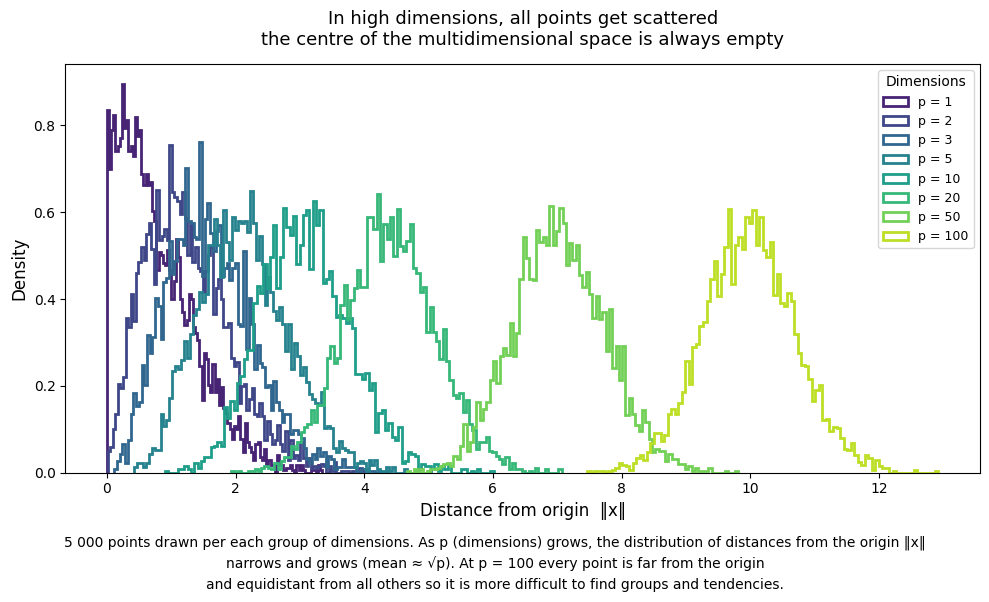

In [15]:
# Create figure and axis with specified size
fig, ax = plt.subplots(figsize=(10, 6))

# Loop through each dimension
for d, c in zip(dims, colors):
    # Generate 5000 random points in d-dimensional space
    # Each coordinate is drawn from standard normal distribution N(0,1)
    # Calculate Euclidean distance from origin for each point
    distances = np.linalg.norm(np.random.randn(5000, d), axis=1)
    
    # Plot histogram as a line (step) showing the density distribution
    # bins=80: number of bins for histogram
    # density=True: normalize to show probability density
    # histtype="step": line plot instead of bars
    ax.hist(distances, bins=100, density=True, histtype="step",
            color=c, lw=2, label=f"p = {d}")

# Customize axis labels
ax.set_xlabel("Distance from origin  ‖x‖", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

# Add legend showing which color corresponds to which dimension
ax.legend(title="Dimensions", title_fontsize=10, fontsize=9)

# Add informative title explaining the phenomenon
ax.set_title("In high dimensions, all points get scattered\n"
             "the centre of the multidimensional space is always empty", fontsize=13, pad=14)

# Add detailed caption explaining the mathematical behavior
fig.text(0.5,0.01,
    "5 000 points drawn per each group of dimensions. As p (dimensions) grows, the distribution of distances from the origin ‖x‖\n"
    "narrows and grows (mean ≈ √p). At p = 100 every point is far from the origin\n"
    "and equidistant from all others so it is more difficult to find groups and tendencies.",
    ha="center", fontsize=10, linespacing=1.6)

# Adjust layout to prevent label cutoff
# rect parameter leaves space at bottom for caption
plt.tight_layout(rect=[0, 0.1, 1, 1])

# Save the figure as high-resolution PNG
plt.savefig("DavidC_COD.png", dpi=150, bbox_inches="tight",
            facecolor="white")

# Display the plot
plt.show()